# Separação de vértebras em rótulos de segmentação

Este notebook processa rótulos originais de segmentação e tenta separar vértebras individuais, como C2, C3, C4 etc., usando componentes conectados ou clusterização espacial. Ele também permite visualizar os clusters encontrados e extrair apenas vértebras específicas, por exemplo C2 e C4.

A ideia é começar simples: se as vértebras já estão desconectadas na máscara, componentes conectados tende a ser mais fiel. Se elas aparecem como uma única massa conectada, use clusterização ao longo do eixo anatômico principal como uma aproximação exploratória.

In [1]:
from pathlib import Path
import os
import sys

import h5py
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage as ndi
from scipy.cluster.vq import kmeans2
from IPython.display import clear_output, display

repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent
os.chdir(repo)
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

print(repo)


/data_ssd/caioseda/projetos/Stable-Diffusion-Seg


## Parâmetros

Preencha `LABEL_PATH` com o rótulo original. Para o VFSS INCA novo, esse caminho normalmente vem da coluna `target_path` do CSV e é resolvido em relação ao diretório do dataset. `IMAGE_PATH` é opcional e serve apenas para overlay visual.

In [2]:
# Modo recomendado: informe uma ou mais pastas target e o notebook cria um índice automaticamente.
USE_DATASET_DIRS = True
DATASET_TARGET_DIRS = [
    Path("/data_ssd/caioseda/data/dataset_inca_all_frames/train/target_pos"),
    Path("/data_ssd/caioseda/data/dataset_inca_all_frames/test/target_pos"),
    Path("/data_ssd/caioseda/data/dataset_inca_all_frames/val/target_pos"),
]
RECURSIVE_DISCOVERY = True
MAX_DATASET_FILES = None  # use um inteiro para limitar durante testes rápidos.
CURRENT_INDEX = 0

# Modo alternativo: caminho de um único rótulo original.
# Exemplos aceitos: .png, .jpg, .tif, .nii.gz, .npy, .npz, .h5.
LABEL_PATH = Path("/data_ssd/caioseda/data/dataset_inca_all_frames/path/para/mascara.png")

# Opcional: imagem anatômica correspondente, para overlay.
IMAGE_PATH = None

# Para .npz/.h5, informe a chave/dataset se o arquivo tiver mais de um array.
LABEL_DATASET_KEY = None
IMAGE_DATASET_KEY = None

# Se None, qualquer valor > FOREGROUND_THRESHOLD vira foreground.
# Use, por exemplo, BINARY_VALUES = [1, 255] se quiser aceitar apenas esses valores.
BINARY_VALUES = None
FOREGROUND_THRESHOLD = 0

# Para volumes 3D, escolha uma fatia ou deixe None para usar projeção máxima.
SLICE_INDEX = None
PROJECTION_MODE = "max"  # "max", "mid" ou "slice"

# Método principal: "connected_components" ou "axis_kmeans".
METHOD = "connected_components"

# Usado pela clusterização e pela nomeação ordenada C2, C3, C4...
N_VERTEBRAE = 7
VERTEBRA_START = "C2"
ANATOMICAL_AXIS = 0  # 0 = linhas/y no display; 1 = colunas/x no display.
ORDER_HIGH_TO_LOW = True  # True: clusters mais altos na imagem recebem C2, depois C3, C4...

# Filtros para componentes conectados.
CONNECTIVITY = 1
MIN_COMPONENT_PIXELS = 25
KEEP_LARGEST = None  # None mantém todos após filtro; use 7 se quiser manter os 7 maiores.

# Máscaras individuais a inspecionar/exportar no final.
SELECTED_VERTEBRAE = ["C2", "C4"]

SUPPORTED_MASK_SUFFIXES = (".tif", ".tiff")


In [3]:
def _first_h5_dataset(group):
    for key, value in group.items():
        if isinstance(value, h5py.Dataset):
            return value[()]
        if isinstance(value, h5py.Group):
            found = _first_h5_dataset(value)
            if found is not None:
                return found
    return None


def load_array(path, dataset_key=None):
    path = Path(path).expanduser()
    if not path.exists():
        raise FileNotFoundError(path)

    name = path.name.lower()
    suffix = path.suffix.lower()

    if name.endswith(".nii") or name.endswith(".nii.gz"):
        return nib.load(str(path)).get_fdata()

    if suffix in {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}:
        return np.asarray(Image.open(path))

    if suffix == ".npy":
        return np.load(path)

    if suffix == ".npz":
        data = np.load(path)
        key = dataset_key or data.files[0]
        return data[key]

    if suffix in {".h5", ".hdf5"}:
        with h5py.File(path, "r") as f:
            if dataset_key is not None:
                return f[dataset_key][()]
            arr = _first_h5_dataset(f)
            if arr is None:
                raise ValueError(f"Nenhum dataset encontrado em {path}")
            return arr

    raise ValueError(f"Extensão não suportada: {path}")


def to_scalar_label(arr):
    arr = np.asarray(arr)
    arr = np.squeeze(arr)

    if arr.ndim >= 3 and arr.shape[-1] in (3, 4):
        arr = arr[..., :3]
        if np.all(arr[..., 0] == arr[..., 1]) and np.all(arr[..., 1] == arr[..., 2]):
            arr = arr[..., 0]
        else:
            arr = np.any(arr > FOREGROUND_THRESHOLD, axis=-1).astype(np.uint8)

    return arr


def to_foreground_mask(arr, binary_values=None, threshold=0):
    arr = to_scalar_label(arr)
    if binary_values is None:
        return arr > threshold
    return np.isin(arr, list(binary_values))


def display_plane(arr, slice_index=None, projection_mode="max"):
    arr = np.asarray(arr)
    if arr.ndim == 2:
        return arr
    if arr.ndim != 3:
        raise ValueError(f"Esperado array 2D ou 3D, recebido shape={arr.shape}")

    if projection_mode == "slice":
        idx = arr.shape[0] // 2 if slice_index is None else slice_index
        return arr[idx]
    if projection_mode == "mid":
        return arr[arr.shape[0] // 2]
    if projection_mode == "max":
        return arr.max(axis=0)

    raise ValueError(f"PROJECTION_MODE inválido: {projection_mode}")


def normalize_image_for_display(arr):
    if arr is None:
        return None
    arr = np.asarray(arr).astype(np.float32)
    arr = np.squeeze(arr)
    if arr.ndim == 3 and arr.shape[-1] in (3, 4):
        arr = arr[..., :3]
    elif arr.ndim == 3:
        arr = display_plane(arr, SLICE_INDEX, PROJECTION_MODE)
    lo, hi = np.nanpercentile(arr, [1, 99])
    arr = np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)
    return arr

## Descoberta automática de máscaras

Quando `USE_DATASET_DIRS=True`, o notebook varre as pastas em `DATASET_TARGET_DIRS`, cria um índice com as máscaras encontradas e tenta inferir a imagem correspondente trocando o diretório `target` por nomes comuns como `image`, `images` ou `frame`.


In [4]:
def resolve_data_path(path):
    path = Path(path).expanduser()
    if path.exists():
        return path.resolve()

    # Aceita caminhos escritos sem a barra inicial, como data_ssd/...
    if not path.is_absolute():
        absolute_candidate = Path("/") / path
        if absolute_candidate.exists():
            return absolute_candidate.resolve()

    return path


def has_supported_suffix(path, suffixes=SUPPORTED_MASK_SUFFIXES):
    name = Path(path).name.lower()
    return any(name.endswith(suffix) for suffix in suffixes)


def discover_mask_paths(target_dirs, recursive=True, max_files=None):
    paths = []
    for target_dir in target_dirs:
        target_dir = resolve_data_path(target_dir)
        if not target_dir.exists():
            print(f"Aviso: pasta não encontrada: {target_dir}")
            continue
        iterator = target_dir.rglob("*") if recursive else target_dir.glob("*")
        paths.extend(p for p in iterator if p.is_file() and has_supported_suffix(p))

    paths = sorted(set(paths))
    if max_files is not None:
        paths = paths[: int(max_files)]
    return paths


def infer_split_from_path(path):
    parts = Path(path).parts
    for split in ("train", "val", "test", "validation"):
        if split in parts:
            return "val" if split == "validation" else split
    return None


def guess_image_path_from_target(mask_path):
    mask_path = Path(mask_path)
    if mask_path.parent.name != "target":
        return None

    split_dir = mask_path.parent.parent
    candidate_dirs = ["image", "images", "frame", "frames", "input", "source"]
    candidate_suffixes = [mask_path.suffix, ".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"]

    for dirname in candidate_dirs:
        image_dir = split_dir / dirname
        if not image_dir.exists():
            continue
        for suffix in candidate_suffixes:
            candidate = image_dir / f"{mask_path.stem}{suffix}"
            if candidate.exists():
                return candidate.resolve()
    return None


def build_mask_index(target_dirs, recursive=True, max_files=None):
    mask_paths = discover_mask_paths(target_dirs, recursive=recursive, max_files=max_files)
    rows = []
    for idx, mask_path in enumerate(mask_paths):
        image_path = guess_image_path_from_target(mask_path)
        rows.append({
            "index": idx,
            "split": infer_split_from_path(mask_path),
            "label_path": str(mask_path),
            "image_path": str(image_path) if image_path is not None else None,
            "filename": mask_path.name,
            "stem": mask_path.stem,
        })
    return pd.DataFrame(rows)


mask_index = pd.DataFrame()
if USE_DATASET_DIRS:
    mask_index = build_mask_index(
        DATASET_TARGET_DIRS,
        recursive=RECURSIVE_DISCOVERY,
        max_files=MAX_DATASET_FILES,
    )
    print(f"Máscaras encontradas: {len(mask_index)}")
    if len(mask_index):
        display(mask_index.head())
else:
    print("USE_DATASET_DIRS=False; usando LABEL_PATH manual.")


Máscaras encontradas: 809


,index,split,label_path,image_path,filename,stem
0,0,test,/data_ssd/caioseda/data/dataset_inca_all_frame...,None,v109_f16.tif,v109_f16
1,1,test,/data_ssd/caioseda/data/dataset_inca_all_frame...,None,v109_f71.tif,v109_f71
2,2,test,/data_ssd/caioseda/data/dataset_inca_all_frame...,None,v109_f72.tif,v109_f72
3,3,test,/data_ssd/caioseda/data/dataset_inca_all_frame...,None,v109_f73.tif,v109_f73
4,4,test,/data_ssd/caioseda/data/dataset_inca_all_frame...,None,v117_f110.tif,v117_f110


## Carregamento e máscara binária

Amostra 1/809
LABEL_PATH: /data_ssd/caioseda/data/dataset_inca_all_frames/test/target_pos/v109_f16.tif
IMAGE_PATH: None
label_raw shape: (1024, 1024) dtype: uint8
foreground_nd shape: (1024, 1024) pixels/voxels: 25255
foreground display shape: (1024, 1024) pixels: 25255


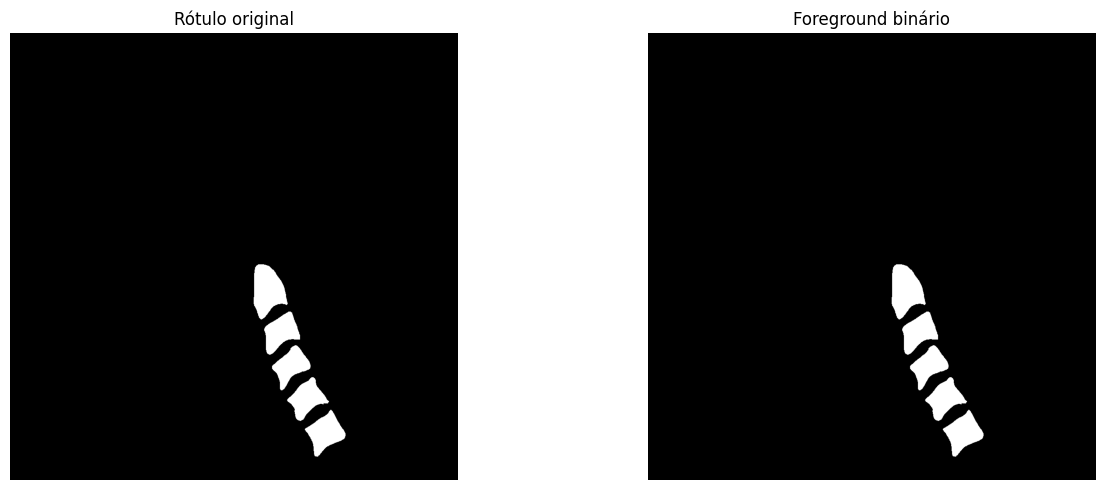

In [5]:
if USE_DATASET_DIRS:
    if mask_index.empty:
        raise ValueError("Nenhuma máscara encontrada. Verifique DATASET_TARGET_DIRS.")
    CURRENT_INDEX = int(np.clip(CURRENT_INDEX, 0, len(mask_index) - 1))
    current_row = mask_index.iloc[CURRENT_INDEX]
    LABEL_PATH = Path(current_row["label_path"])
    IMAGE_PATH = None if pd.isna(current_row["image_path"]) else Path(current_row["image_path"])
    print(f"Amostra {CURRENT_INDEX + 1}/{len(mask_index)}")
    print("LABEL_PATH:", LABEL_PATH)
    print("IMAGE_PATH:", IMAGE_PATH)

label_raw = load_array(LABEL_PATH, LABEL_DATASET_KEY)
foreground_nd = to_foreground_mask(label_raw, BINARY_VALUES, FOREGROUND_THRESHOLD)
foreground = display_plane(foreground_nd.astype(np.uint8), SLICE_INDEX, PROJECTION_MODE).astype(bool)

image_display = None
if IMAGE_PATH is not None:
    image_display = normalize_image_for_display(load_array(IMAGE_PATH, IMAGE_DATASET_KEY))

print("label_raw shape:", np.asarray(label_raw).shape, "dtype:", np.asarray(label_raw).dtype)
print("foreground_nd shape:", foreground_nd.shape, "pixels/voxels:", int(foreground_nd.sum()))
print("foreground display shape:", foreground.shape, "pixels:", int(foreground.sum()))

fig, axes = plt.subplots(1, 2 if image_display is None else 3, figsize=(14, 5))
axes = np.atleast_1d(axes)
axes[0].imshow(display_plane(to_scalar_label(label_raw), SLICE_INDEX, PROJECTION_MODE), cmap="gray")
axes[0].set_title("Rótulo original")
axes[0].axis("off")
axes[1].imshow(foreground, cmap="gray")
axes[1].set_title("Foreground binário")
axes[1].axis("off")
if image_display is not None:
    axes[2].imshow(image_display, cmap="gray")
    axes[2].imshow(np.ma.masked_where(~foreground, foreground), cmap="autumn", alpha=0.45)
    axes[2].set_title("Overlay")
    axes[2].axis("off")
plt.tight_layout()


## Separação por componentes conectados ou clusterização

In [6]:
def connected_component_labels(mask, connectivity=1, min_pixels=1, keep_largest=None):
    structure = ndi.generate_binary_structure(mask.ndim, connectivity)
    labeled, n_labels = ndi.label(mask, structure=structure)

    rows = []
    for label_id in range(1, n_labels + 1):
        coords = np.argwhere(labeled == label_id)
        area = coords.shape[0]
        if area < min_pixels:
            continue
        rows.append({
            "label_id": label_id,
            "area": area,
            "centroid_axis0": float(coords[:, 0].mean()),
            "centroid_axis1": float(coords[:, 1].mean()),
        })

    stats = pd.DataFrame(rows)
    if stats.empty:
        return np.zeros_like(labeled, dtype=np.int32), stats

    if keep_largest is not None:
        stats = stats.sort_values("area", ascending=False).head(int(keep_largest))

    remapped = np.zeros_like(labeled, dtype=np.int32)
    for new_id, old_id in enumerate(stats["label_id"], start=1):
        remapped[labeled == old_id] = new_id

    stats = component_stats(remapped)
    return remapped, stats


def axis_kmeans_labels(mask, n_clusters, axis=0):
    coords = np.argwhere(mask)
    if coords.shape[0] == 0:
        return np.zeros(mask.shape, dtype=np.int32), pd.DataFrame()
    if coords.shape[0] < n_clusters:
        raise ValueError("Foreground menor que N_VERTEBRAE; reduza N_VERTEBRAE.")

    values = coords[:, [axis]].astype(np.float32)
    initial = np.linspace(values.min(), values.max(), n_clusters, dtype=np.float32).reshape(-1, 1)
    centroids, cluster_ids = kmeans2(values, initial, minit="matrix", iter=100)

    labels = np.zeros(mask.shape, dtype=np.int32)
    for idx, coord in enumerate(coords):
        labels[tuple(coord)] = int(cluster_ids[idx]) + 1

    return labels, component_stats(labels)


def component_stats(labels):
    rows = []
    for label_id in sorted(int(v) for v in np.unique(labels) if v != 0):
        coords = np.argwhere(labels == label_id)
        if coords.size == 0:
            continue
        rows.append({
            "label_id": label_id,
            "area": int(coords.shape[0]),
            "centroid_axis0": float(coords[:, 0].mean()),
            "centroid_axis1": float(coords[:, 1].mean()),
            "min_axis0": int(coords[:, 0].min()),
            "max_axis0": int(coords[:, 0].max()),
            "min_axis1": int(coords[:, 1].min()),
            "max_axis1": int(coords[:, 1].max()),
        })
    return pd.DataFrame(rows)


def vertebra_names(start="C2", n=7):
    prefix = start[0].upper()
    first = int(start[1:])
    return [f"{prefix}{i}" for i in range(first, first + n)]


def assign_vertebra_names(labels, stats, start="C2", axis=0, high_to_low=True):
    if stats.empty:
        return labels, stats

    centroid_col = f"centroid_axis{axis}"
    ordered = stats.sort_values(centroid_col, ascending=high_to_low).reset_index(drop=True)
    names = vertebra_names(start, len(ordered))
    mapping = dict(zip(ordered["label_id"], range(1, len(ordered) + 1)))

    renamed = np.zeros_like(labels, dtype=np.int32)
    for old_id, new_id in mapping.items():
        renamed[labels == int(old_id)] = int(new_id)

    ordered["vertebra"] = names
    ordered["ordered_id"] = list(range(1, len(ordered) + 1))
    return renamed, ordered


if METHOD == "connected_components":
    cluster_labels, cluster_stats = connected_component_labels(
        foreground,
        connectivity=CONNECTIVITY,
        min_pixels=MIN_COMPONENT_PIXELS,
        keep_largest=KEEP_LARGEST,
    )
elif METHOD == "axis_kmeans":
    cluster_labels, cluster_stats = axis_kmeans_labels(foreground, N_VERTEBRAE, axis=ANATOMICAL_AXIS)
else:
    raise ValueError(f"METHOD inválido: {METHOD}")

vertebra_labels, vertebra_stats = assign_vertebra_names(
    cluster_labels,
    cluster_stats,
    start=VERTEBRA_START,
    axis=ANATOMICAL_AXIS,
    high_to_low=ORDER_HIGH_TO_LOW,
)

display(vertebra_stats)

,label_id,area,centroid_axis0,centroid_axis1,min_axis0,max_axis0,min_axis1,max_axis1,vertebra,ordered_id
0,1,6486,590.003700,588.175917,531,656,557,634,C2,1
1,2,4647,685.726060,618.637400,639,737,581,662,C3,2
2,3,4390,762.474715,641.681093,716,818,599,686,C4,3
3,4,4621,837.699199,677.822766,789,888,633,728,C5,4
4,5,5111,915.658775,720.477597,863,970,674,766,C6,5


## Visualização dos clusters

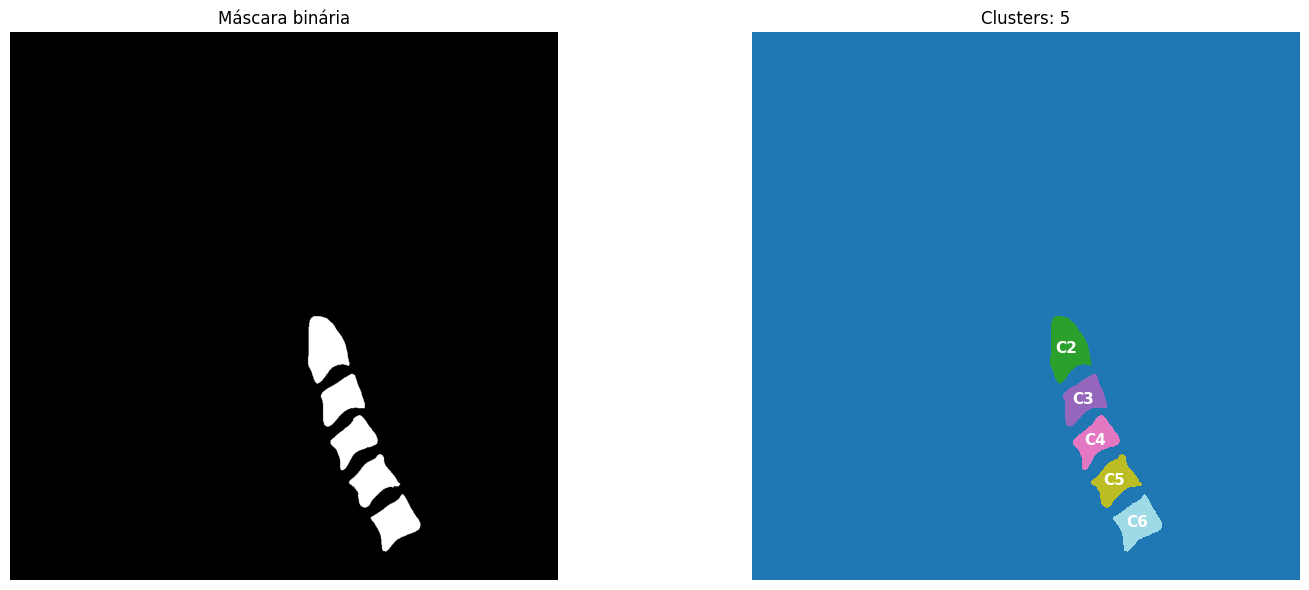

In [7]:
def label_to_rgba(labels):
    labels = np.asarray(labels)
    cmap = plt.get_cmap("tab20", int(labels.max()) + 1)
    rgba = cmap(labels)
    rgba[..., 3] = np.where(labels > 0, 0.75, 0.0)
    return rgba


def plot_clusters(mask, labels, stats, image=None):
    fig, axes = plt.subplots(1, 3 if image is not None else 2, figsize=(16, 6))
    axes = np.atleast_1d(axes)

    axes[0].imshow(mask, cmap="gray")
    axes[0].set_title("Máscara binária")
    axes[0].axis("off")

    axes[1].imshow(labels, cmap="tab20", interpolation="nearest")
    axes[1].set_title(f"Clusters: {int(labels.max())}")
    axes[1].axis("off")

    if image is not None:
        axes[2].imshow(image, cmap="gray")
        axes[2].imshow(label_to_rgba(labels))
        axes[2].set_title("Overlay dos clusters")
        axes[2].axis("off")

    for ax in axes[1:]:
        for _, row in stats.iterrows():
            y = row["centroid_axis0"]
            x = row["centroid_axis1"]
            label = row.get("vertebra", str(int(row["label_id"])))
            ax.text(x, y, label, color="white", fontsize=11, ha="center", va="center", weight="bold")

    plt.tight_layout()


plot_clusters(foreground, vertebra_labels, vertebra_stats, image_display)

## Navegação interativa pelo dataset

Execute esta célula depois de construir `mask_index`. Use as setas ou o slider para percorrer as máscaras e conferir o resultado do clustering. Se `ipywidgets` não estiver instalado no kernel, use `render_dataset_item(indice)` manualmente.


In [8]:
def cluster_foreground(mask):
    if METHOD == "connected_components":
        cluster_labels, cluster_stats = connected_component_labels(
            mask,
            connectivity=CONNECTIVITY,
            min_pixels=MIN_COMPONENT_PIXELS,
            keep_largest=KEEP_LARGEST,
        )
    elif METHOD == "axis_kmeans":
        cluster_labels, cluster_stats = axis_kmeans_labels(mask, N_VERTEBRAE, axis=ANATOMICAL_AXIS)
    else:
        raise ValueError(f"METHOD inválido: {METHOD}")

    vertebra_labels, vertebra_stats = assign_vertebra_names(
        cluster_labels,
        cluster_stats,
        start=VERTEBRA_START,
        axis=ANATOMICAL_AXIS,
        high_to_low=ORDER_HIGH_TO_LOW,
    )
    return vertebra_labels, vertebra_stats


def process_label_path(label_path, image_path=None):
    label_raw_local = load_array(label_path, LABEL_DATASET_KEY)
    foreground_nd_local = to_foreground_mask(label_raw_local, BINARY_VALUES, FOREGROUND_THRESHOLD)
    foreground_local = display_plane(
        foreground_nd_local.astype(np.uint8),
        SLICE_INDEX,
        PROJECTION_MODE,
    ).astype(bool)

    image_display_local = None
    if image_path is not None and not pd.isna(image_path):
        image_path = Path(image_path)
        if image_path.exists():
            image_display_local = normalize_image_for_display(load_array(image_path, IMAGE_DATASET_KEY))

    vertebra_labels_local, vertebra_stats_local = cluster_foreground(foreground_local)
    return {
        "label_path": Path(label_path),
        "image_path": None if image_path is None or pd.isna(image_path) else Path(image_path),
        "label_raw": label_raw_local,
        "foreground": foreground_local,
        "image_display": image_display_local,
        "vertebra_labels": vertebra_labels_local,
        "vertebra_stats": vertebra_stats_local,
    }


def process_dataset_index(index):
    if mask_index.empty:
        raise ValueError("mask_index está vazio. Ative USE_DATASET_DIRS ou verifique DATASET_TARGET_DIRS.")
    index = int(np.clip(index, 0, len(mask_index) - 1))
    row = mask_index.iloc[index]
    result = process_label_path(row["label_path"], row["image_path"])
    result["dataset_index"] = index
    result["dataset_row"] = row
    return result


def selected_masks_from_result(result, selected_vertebrae=SELECTED_VERTEBRAE):
    stats = result["vertebra_stats"]
    labels = result["vertebra_labels"]
    if stats.empty:
        return {}, np.zeros_like(labels, dtype=np.uint8)

    name_to_id = dict(zip(stats["vertebra"], stats["ordered_id"]))
    selected_masks = {}
    combined = np.zeros_like(labels, dtype=np.uint8)
    for out_id, vertebra in enumerate(selected_vertebrae, start=1):
        if vertebra not in name_to_id:
            continue
        mask_i = labels == int(name_to_id[vertebra])
        selected_masks[vertebra] = mask_i
        combined[mask_i] = out_id
    return selected_masks, combined


def render_dataset_item(index, show_stats=True):
    result = process_dataset_index(index)
    row = result["dataset_row"]
    print(f"Amostra {index + 1}/{len(mask_index)} | split={row.get('split')} | {row.get('filename')}")
    print("label:", result["label_path"])
    if result["image_path"] is not None:
        print("image:", result["image_path"])

    plot_clusters(
        result["foreground"],
        result["vertebra_labels"],
        result["vertebra_stats"],
        result["image_display"],
    )
    plt.show()

    selected_masks, combined_selected = selected_masks_from_result(result)
    if selected_masks:
        fig, axes = plt.subplots(1, len(selected_masks) + 1, figsize=(5 * (len(selected_masks) + 1), 5))
        axes = np.atleast_1d(axes).ravel()
        axes[0].imshow(combined_selected, cmap="tab10", interpolation="nearest")
        axes[0].set_title("Selecionadas")
        axes[0].axis("off")
        for ax, (vertebra, mask_i) in zip(axes[1:], selected_masks.items()):
            if result["image_display"] is None:
                ax.imshow(mask_i, cmap="gray")
            else:
                ax.imshow(result["image_display"], cmap="gray")
                ax.imshow(np.ma.masked_where(~mask_i, mask_i), cmap="autumn", alpha=0.55)
            ax.set_title(vertebra)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    if show_stats:
        display(result["vertebra_stats"])
    return result


In [9]:
try:
    import ipywidgets as widgets

    if mask_index.empty:
        print("mask_index está vazio; não há dataset para navegar.")
    else:
        output = widgets.Output()
        index_slider = widgets.IntSlider(
            value=int(np.clip(CURRENT_INDEX, 0, len(mask_index) - 1)),
            min=0,
            max=len(mask_index) - 1,
            step=1,
            description="índice",
            continuous_update=False,
            layout=widgets.Layout(width="520px"),
        )
        prev_button = widgets.Button(description="←", tooltip="Máscara anterior", layout=widgets.Layout(width="48px"))
        next_button = widgets.Button(description="→", tooltip="Próxima máscara", layout=widgets.Layout(width="48px"))

        def redraw(change=None):
            with output:
                clear_output(wait=True)
                render_dataset_item(index_slider.value)

        def go_previous(_):
            index_slider.value = max(index_slider.min, index_slider.value - 1)

        def go_next(_):
            index_slider.value = min(index_slider.max, index_slider.value + 1)

        prev_button.on_click(go_previous)
        next_button.on_click(go_next)
        index_slider.observe(redraw, names="value")

        display(widgets.HBox([prev_button, next_button, index_slider]))
        display(output)
        redraw()
except ImportError:
    print("ipywidgets não está instalado neste kernel.")
    print("Use render_dataset_item(0), render_dataset_item(1), ... para navegar manualmente.")

Output()


casos ruins:

- 33 : [/data_ssd/caioseda/data/dataset_inca_all_frames/test/target/v159_f203.tif](/data_ssd/caioseda/data/dataset_inca_all_frames/test/target/v159_f203.tif)
- 167: [/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v101_f205.tif](/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v101_f205.tif)
- 328: [/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v154_f187.tif](/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v154_f187.tif)
- 456: [/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v1_f85.tif](/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v1_f85.tif)
- 472: [/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v212_f99.tif](/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v212_f99.tif)
- 561: [/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v41_f215.tif](/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v41_f215.tif)
- 581: [/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v50_f134.tif](/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v50_f134.tif)
- 603: [/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v58_f14.tif](/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v58_f14.tif)
- 681: [/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v84_f144.tif](/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v84_f144.tif)
- 719: [/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v98_f45.tif](/data_ssd/caioseda/data/dataset_inca_all_frames/train/target/v98_f45.tif)
- 746: [/data_ssd/caioseda/data/dataset_inca_all_frames/val/target/v157_f187.tif](/data_ssd/caioseda/data/dataset_inca_all_frames/val/target/v157_f187.tif)


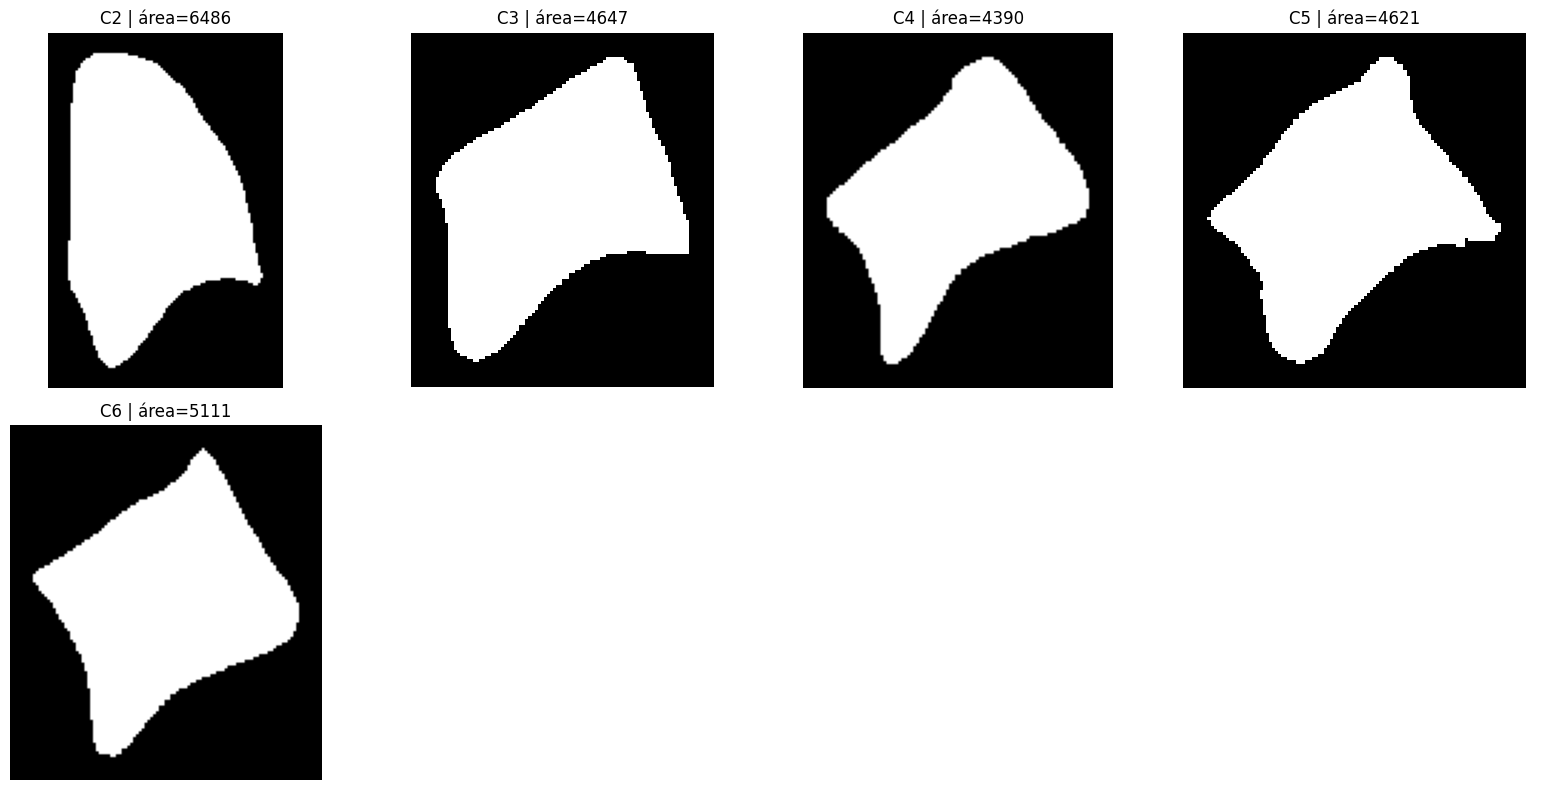

In [10]:
def crop_with_padding(mask, pad=8):
    coords = np.argwhere(mask)
    if coords.size == 0:
        return mask, (slice(0, mask.shape[0]), slice(0, mask.shape[1]))
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(mask.shape[0], y1 + pad)
    x1 = min(mask.shape[1], x1 + pad)
    slices = (slice(y0, y1), slice(x0, x1))
    return mask[slices], slices


n = int(vertebra_labels.max())
cols = min(4, max(1, n))
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.atleast_1d(axes).ravel()

for idx in range(1, n + 1):
    ax = axes[idx - 1]
    row = vertebra_stats.loc[vertebra_stats["ordered_id"] == idx].iloc[0]
    mask_i = vertebra_labels == idx
    cropped, slices = crop_with_padding(mask_i)
    if image_display is None:
        ax.imshow(cropped, cmap="gray")
    else:
        ax.imshow(image_display[slices], cmap="gray")
        ax.imshow(np.ma.masked_where(~cropped, cropped), cmap="autumn", alpha=0.55)
    ax.set_title(f"{row['vertebra']} | área={int(row['area'])}")
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()

## Separar apenas C2 e C4

Esta seção cria máscaras binárias separadas para as vértebras em `SELECTED_VERTEBRAE`. Se C2 ou C4 parecerem trocadas, ajuste `ORDER_HIGH_TO_LOW` ou `ANATOMICAL_AXIS` e rode novamente a partir da seção de separação.

Máscaras selecionadas: ['C2', 'C4']


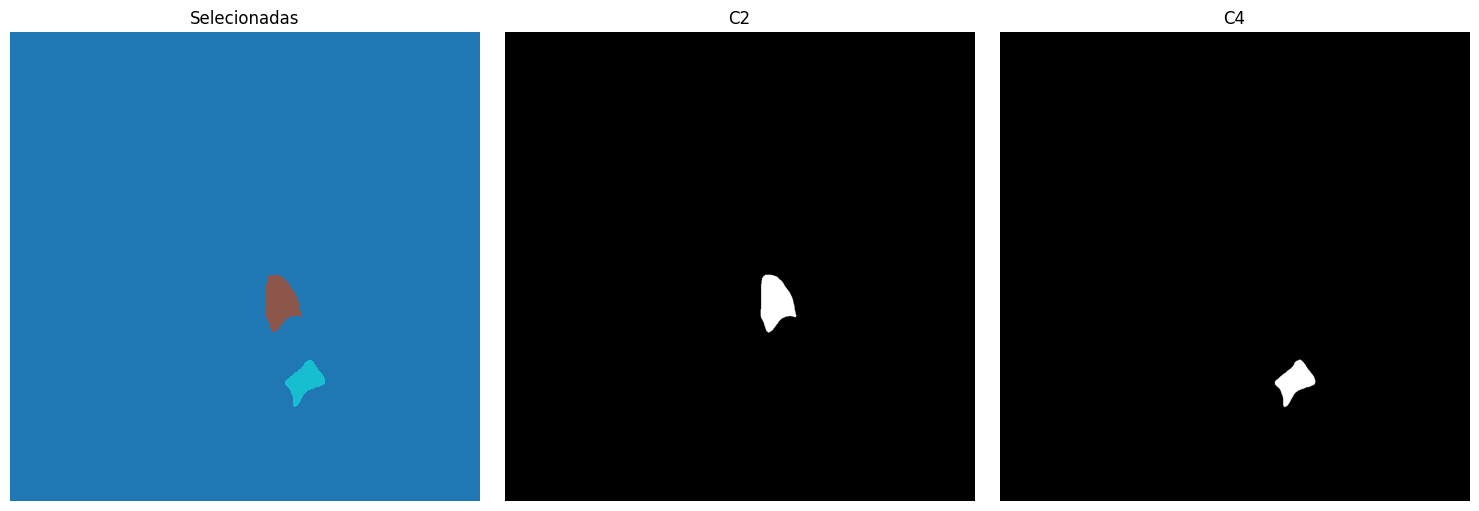

In [11]:
name_to_id = dict(zip(vertebra_stats["vertebra"], vertebra_stats["ordered_id"]))
selected_masks = {}

for vertebra in SELECTED_VERTEBRAE:
    if vertebra not in name_to_id:
        print(f"{vertebra}: não encontrada. Disponíveis: {sorted(name_to_id)}")
        continue
    selected_masks[vertebra] = vertebra_labels == int(name_to_id[vertebra])

combined_selected_mask = np.zeros_like(vertebra_labels, dtype=np.uint8)
for idx, vertebra in enumerate(selected_masks, start=1):
    combined_selected_mask[selected_masks[vertebra]] = idx

print("Máscaras selecionadas:", list(selected_masks))

fig, axes = plt.subplots(1, max(1, len(selected_masks)) + 1, figsize=(5 * (len(selected_masks) + 1), 5))
axes = np.atleast_1d(axes).ravel()

axes[0].imshow(combined_selected_mask, cmap="tab10", interpolation="nearest")
axes[0].set_title("Selecionadas")
axes[0].axis("off")

for ax, (vertebra, mask_i) in zip(axes[1:], selected_masks.items()):
    if image_display is None:
        ax.imshow(mask_i, cmap="gray")
    else:
        ax.imshow(image_display, cmap="gray")
        ax.imshow(np.ma.masked_where(~mask_i, mask_i), cmap="autumn", alpha=0.55)
    ax.set_title(vertebra)
    ax.axis("off")

plt.tight_layout()

## Exploração da área dos clusters

Esta seção processa o índice inteiro e resume a área de cada cluster/vértebra. Use os maiores e menores casos para procurar máscaras quebradas, componentes espúrios, falhas de ordenação ou vértebras agrupadas indevidamente.


In [12]:
RUN_AREA_SCAN = True
MAX_AREA_SCAN_FILES = None  # use um inteiro para uma checagem rápida.


def scan_cluster_areas(index_df=None, max_files=None):
    if index_df is None:
        index_df = mask_index
    if index_df.empty:
        raise ValueError("mask_index está vazio; não há máscaras para analisar.")

    if max_files is not None:
        index_df = index_df.head(int(max_files))

    rows = []
    failures = []
    for pos, (_, row) in enumerate(index_df.iterrows(), start=1):
        try:
            result = process_label_path(row["label_path"], row.get("image_path"))
            stats = result["vertebra_stats"].copy()
            if stats.empty:
                rows.append({
                    "dataset_index": int(row["index"]),
                    "split": row.get("split"),
                    "filename": row.get("filename"),
                    "label_path": row["label_path"],
                    "vertebra": None,
                    "ordered_id": None,
                    "area": 0,
                    "n_clusters": 0,
                    "foreground_area": int(result["foreground"].sum()),
                })
            else:
                stats["dataset_index"] = int(row["index"])
                stats["split"] = row.get("split")
                stats["filename"] = row.get("filename")
                stats["label_path"] = row["label_path"]
                stats["n_clusters"] = int(result["vertebra_labels"].max())
                stats["foreground_area"] = int(result["foreground"].sum())
                rows.extend(stats.to_dict("records"))
        except Exception as exc:
            failures.append({
                "dataset_index": int(row["index"]),
                "filename": row.get("filename"),
                "label_path": row["label_path"],
                "error": repr(exc),
            })

        if pos % 50 == 0:
            print(f"Processadas {pos}/{len(index_df)} máscaras...")

    area_df = pd.DataFrame(rows)
    failures_df = pd.DataFrame(failures)
    return area_df, failures_df


if RUN_AREA_SCAN:
    area_df, area_failures_df = scan_cluster_areas(max_files=MAX_AREA_SCAN_FILES)
    print(f"clusters analisados: {len(area_df)}")
    print(f"falhas: {len(area_failures_df)}")
    display(area_df.head())
    if len(area_failures_df):
        display(area_failures_df.head())
else:
    area_df = pd.DataFrame()
    area_failures_df = pd.DataFrame()
    print("RUN_AREA_SCAN=False; ative para processar o dataset.")


Processadas 50/809 máscaras...
Processadas 100/809 máscaras...
Processadas 150/809 máscaras...
Processadas 200/809 máscaras...
Processadas 250/809 máscaras...
Processadas 300/809 máscaras...
Processadas 350/809 máscaras...
Processadas 400/809 máscaras...
Processadas 450/809 máscaras...
Processadas 500/809 máscaras...
Processadas 550/809 máscaras...
Processadas 600/809 máscaras...
Processadas 650/809 máscaras...
Processadas 700/809 máscaras...
Processadas 750/809 máscaras...
Processadas 800/809 máscaras...
clusters analisados: 3751
falhas: 0


,label_id,area,centroid_axis0,centroid_axis1,min_axis0,max_axis0,min_axis1,max_axis1,vertebra,ordered_id,dataset_index,split,filename,label_path,n_clusters,foreground_area
0,1,6486,590.003700,588.175917,531,656,557,634,C2,1,0,test,v109_f16.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,5,25255
1,2,4647,685.726060,618.637400,639,737,581,662,C3,2,0,test,v109_f16.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,5,25255
2,3,4390,762.474715,641.681093,716,818,599,686,C4,3,0,test,v109_f16.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,5,25255
3,4,4621,837.699199,677.822766,789,888,633,728,C5,4,0,test,v109_f16.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,5,25255
4,5,5111,915.658775,720.477597,863,970,674,766,C6,5,0,test,v109_f16.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,5,25255


In [13]:
def area_summary_tables(area_df):
    if area_df.empty:
        print("area_df está vazio.")
        return None

    valid = area_df[area_df["area"] > 0].copy()
    per_vertebra = (
        valid.groupby("vertebra", dropna=False)
        .agg(
            examples=("dataset_index", "nunique"),
            min_area=("area", "min"),
            median_area=("area", "median"),
            mean_area=("area", "mean"),
            max_area=("area", "max"),
        )
        .reset_index()
        .sort_values("vertebra")
    )

    per_mask = (
        area_df.groupby(["dataset_index", "split", "filename", "label_path"], dropna=False)
        .agg(
            n_clusters=("n_clusters", "max"),
            foreground_area=("foreground_area", "max"),
            min_cluster_area=("area", "min"),
            max_cluster_area=("area", "max"),
            median_cluster_area=("area", "median"),
        )
        .reset_index()
    )
    per_mask["area_ratio_max_min"] = per_mask["max_cluster_area"] / per_mask["min_cluster_area"].clip(lower=1)

    print("Resumo por vértebra")
    display(per_vertebra)
    print("Máscaras com menores clusters")
    display(per_mask.sort_values("min_cluster_area", ascending=True).head(10))
    print("Máscaras com maiores clusters")
    display(per_mask.sort_values("max_cluster_area", ascending=False).head(10))
    print("Máscaras com maior razão entre maior e menor cluster")
    display(per_mask.sort_values("area_ratio_max_min", ascending=False).head(10))
    return per_vertebra, per_mask


summary = area_summary_tables(area_df) if not area_df.empty else None
if summary is not None:
    per_vertebra_area, per_mask_area = summary


Resumo por vértebra


,vertebra,examples,min_area,median_area,mean_area,max_area
0,C2,809,1006,5912.0,5884.384425,15518
1,C3,809,625,4278.0,4294.893696,10237
2,C4,809,683,4252.0,4275.557478,10254
3,C5,751,709,4296.0,4250.157124,9997
4,C6,408,775,4434.0,4485.036765,9916
5,C7,149,729,4843.0,4659.671141,9808
6,C8,16,4374,7708.5,7497.375000,8609


Máscaras com menores clusters


,dataset_index,split,filename,label_path,n_clusters,foreground_area,min_cluster_area,max_cluster_area,median_cluster_area,area_ratio_max_min
564,564,train,v43_f3.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,5,4836,625,1373,938.0,2.196800
801,801,val,v88_f136.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,3493,683,1127,841.5,1.650073
702,702,train,v93_f47.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,3417,709,1093,807.5,1.541608
807,807,val,v90_f76.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,4134,712,1402,1010.0,1.969101
802,802,val,v88_f148.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,6,4886,729,1032,775.0,1.415638
804,804,val,v88_f81.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,3495,748,1100,823.5,1.470588
723,723,train,v99_f55.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,6,5547,776,1234,863.5,1.590206
703,703,train,v93_f52.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,6,5892,789,1366,898.0,1.731305
150,150,test,v86_f155.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,3871,801,1215,927.5,1.516854
694,694,train,v8_f93.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,6,7126,818,1546,1191.0,1.889976


Máscaras com maiores clusters


,dataset_index,split,filename,label_path,n_clusters,foreground_area,min_cluster_area,max_cluster_area,median_cluster_area,area_ratio_max_min
483,483,train,v221_f35.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,43506,9126,15518,9431.0,1.700416
767,767,val,v222_f20.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,43270,9129,15106,9517.5,1.654727
769,769,val,v222_f50.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,42720,8482,14447,9895.5,1.703254
486,486,train,v223_f13.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,41628,8716,13942,9485.0,1.599587
770,770,val,v222_f59.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,42507,9142,13904,9730.5,1.520893
487,487,train,v223_f24.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,5,50474,8403,13862,9696.0,1.649649
484,484,train,v221_f51.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,41351,8562,13850,9469.5,1.617613
485,485,train,v223_f10.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,41596,8967,13306,9661.0,1.483885
768,768,val,v222_f229.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,41676,8293,13099,10142.0,1.579525
771,771,val,v225_f171.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,5,45898,7169,12889,8937.0,1.797880


Máscaras com maior razão entre maior e menor cluster


,dataset_index,split,filename,label_path,n_clusters,foreground_area,min_cluster_area,max_cluster_area,median_cluster_area,area_ratio_max_min
389,389,train,v172_f41.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,6,29352,3698,10092,3876.5,2.729043
752,752,val,v177_f31.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,5,23028,3509,7811,3926.0,2.225990
327,327,train,v154_f135.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,7,35499,3406,7557,4950.0,2.218732
564,564,train,v43_f3.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,5,4836,625,1373,938.0,2.196800
111,111,test,v35_f88.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,16067,2883,6323,3430.5,2.193202
746,746,val,v157_f187.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,5,32554,4589,9916,5497.0,2.160819
351,351,train,v161_f143.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,26304,4918,10331,5527.5,2.100651
146,146,test,v77_f128.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,4,20345,3786,7853,4353.0,2.074221
407,407,train,v181_f255.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,6,26291,2921,5996,4401.5,2.052722
278,278,train,v13_f100.tif,/data_ssd/caioseda/data/dataset_inca_all_frame...,6,32613,4227,8608,4975.5,2.036432


In [14]:
def plot_area_extremes(area_df, by="cluster", largest=True, top_n=6):
    if area_df.empty:
        print("area_df está vazio.")
        return []

    if by == "cluster":
        candidates = area_df[area_df["area"] > 0].sort_values("area", ascending=not largest).head(top_n)
        indexes = candidates["dataset_index"].astype(int).tolist()
    elif by == "mask_min_cluster":
        per_mask = (
            area_df.groupby("dataset_index", dropna=False)
            .agg(metric=("area", "min"))
            .reset_index()
            .sort_values("metric", ascending=not largest)
            .head(top_n)
        )
        indexes = per_mask["dataset_index"].astype(int).tolist()
    elif by == "mask_max_cluster":
        per_mask = (
            area_df.groupby("dataset_index", dropna=False)
            .agg(metric=("area", "max"))
            .reset_index()
            .sort_values("metric", ascending=not largest)
            .head(top_n)
        )
        indexes = per_mask["dataset_index"].astype(int).tolist()
    else:
        raise ValueError("by deve ser 'cluster', 'mask_min_cluster' ou 'mask_max_cluster'.")

    unique_indexes = []
    for idx in indexes:
        if idx not in unique_indexes:
            unique_indexes.append(idx)

    rendered = []
    for idx in unique_indexes:
        print("=" * 100)
        rendered.append(render_dataset_item(idx, show_stats=True))
    return rendered


# Exemplos úteis para inspeção manual:
# maiores_clusters = plot_area_extremes(area_df, by="cluster", largest=True, top_n=6)
# menores_clusters = plot_area_extremes(area_df, by="cluster", largest=False, top_n=6)
# mascaras_com_menores_componentes = plot_area_extremes(area_df, by="mask_min_cluster", largest=False, top_n=6)


## Exportação opcional

Ative `SAVE_DATASET_OUTPUTS` para processar o índice inteiro e salvar arquivos `.tiff` separados por `train`, `val` e `test`. O padrão multiclasse usa `0` como fundo e `1..N` como índices das vértebras ordenadas a partir de `VERTEBRA_START` (`C2=1`, `C3=2`, ...). Também é possível salvar uma versão multiclasse só com `SELECTED_VERTEBRAE` e uma versão binária combinada, onde apenas essas vértebras ficam como foreground.

In [16]:
SAVE_SINGLE_SAMPLE_OUTPUTS = True
SAVE_DATASET_OUTPUTS = True

SAVE_FULL_MULTICLASS_TIFFS = True
SAVE_SELECTED_MULTICLASS_TIFFS = True
SAVE_SELECTED_BINARY_TIFFS = True
SELECTED_MULTICLASS_USE_COMPACT_IDS = True  # True: C2=1, C4=2; False: mantém IDs globais, ex. C2=1, C4=3.
SELECTED_BINARY_FOREGROUND_VALUE = 255  # use 255 se quiser máscaras binárias visualmente brancas.
EXPORT_OUTPUT_DIR = repo / "outputs" / "vertebra_label_clustering"
FULL_MULTICLASS_DIRNAME = "multiclass_all"
SELECTED_MULTICLASS_DIRNAME = f"multiclass_{'_'.join(SELECTED_VERTEBRAE)}"
SELECTED_BINARY_DIRNAME = f"binary_{'_'.join(SELECTED_VERTEBRAE)}"
EXPORT_TIFF_SUFFIX = ".tif"
EXPORT_PREFIX_DATASET_INDEX = False
MAX_EXPORT_FILES = None  # use um inteiro para testar a exportação em poucos arquivos.


def _multiclass_dtype(max_label):
    return np.uint8 if max_label <= np.iinfo(np.uint8).max else np.uint16


def labels_to_save_array(labels):
    labels = np.asarray(labels)
    max_label = int(labels.max()) if labels.size else 0
    return labels.astype(_multiclass_dtype(max_label), copy=False)


def save_multiclass_tiff(labels, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(labels_to_save_array(labels)).save(path, format="TIFF")
    return path


def selected_multiclass_labels(
    labels,
    stats,
    selected_vertebrae=SELECTED_VERTEBRAE,
    compact_ids=SELECTED_MULTICLASS_USE_COMPACT_IDS,
    warn_missing=True,
):
    selected = np.zeros_like(labels, dtype=np.int32)
    columns = ["vertebra", "source_ordered_id", "export_id"]
    if stats.empty:
        return selected, pd.DataFrame(columns=columns)

    name_to_id = dict(zip(stats["vertebra"], stats["ordered_id"]))
    rows = []
    for compact_id, vertebra in enumerate(selected_vertebrae, start=1):
        if vertebra not in name_to_id:
            if warn_missing:
                print(f"{vertebra}: não encontrada. Disponíveis: {sorted(name_to_id)}")
            continue
        source_id = int(name_to_id[vertebra])
        export_id = int(compact_id if compact_ids else source_id)
        selected[labels == source_id] = export_id
        rows.append({"vertebra": vertebra, "source_ordered_id": source_id, "export_id": export_id})
    return selected, pd.DataFrame(rows, columns=columns)


def selected_binary_labels(selected_labels, foreground_value=SELECTED_BINARY_FOREGROUND_VALUE):
    return (np.asarray(selected_labels) > 0).astype(np.uint8) * np.uint8(foreground_value)


def class_mapping_from_stats(stats):
    columns = ["vertebra", "source_ordered_id", "export_id"]
    if stats.empty:
        return pd.DataFrame(columns=columns)
    mapping = stats[["vertebra", "ordered_id"]].rename(columns={"ordered_id": "export_id"}).copy()
    mapping["source_ordered_id"] = mapping["export_id"].astype(int)
    return mapping[columns]


def export_filename(row):
    filename = row.get("filename")
    if filename is None or pd.isna(filename):
        stem = Path(row["label_path"]).stem
    else:
        stem = Path(str(filename)).stem
    if EXPORT_PREFIX_DATASET_INDEX:
        stem = f"{int(row['index']):05d}_{stem}"
    return f"{stem}{EXPORT_TIFF_SUFFIX}"


def export_path(output_dir, dirname, row):
    split = row.get("split")
    split = "unknown" if split is None or pd.isna(split) else str(split)
    return Path(output_dir) / dirname / split / export_filename(row)


def export_current_sample_multiclass(output_dir=EXPORT_OUTPUT_DIR):
    output_dir = Path(output_dir)
    paths = {}

    full_path = output_dir / "current_sample" / "vertebra_labels.tiff"
    paths["full_multiclass_path"] = str(save_multiclass_tiff(vertebra_labels, full_path))
    class_mapping_from_stats(vertebra_stats).to_csv(
        output_dir / "current_sample" / "class_mapping.csv",
        index=False,
    )

    selected_labels, selected_mapping = selected_multiclass_labels(
        vertebra_labels,
        vertebra_stats,
        compact_ids=SELECTED_MULTICLASS_USE_COMPACT_IDS,
    )
    selected_path = output_dir / "current_sample" / f"selected_{'_'.join(SELECTED_VERTEBRAE)}.tiff"
    paths["selected_multiclass_path"] = str(save_multiclass_tiff(selected_labels, selected_path))
    selected_mapping.to_csv(output_dir / "current_sample" / "selected_class_mapping.csv", index=False)

    selected_binary_path = output_dir / "current_sample" / f"binary_{'_'.join(SELECTED_VERTEBRAE)}.tiff"
    paths["selected_binary_path"] = str(save_multiclass_tiff(selected_binary_labels(selected_labels), selected_binary_path))

    print("Amostra atual exportada em:", output_dir / "current_sample")
    return paths


def export_dataset_multiclass(index_df=None, output_dir=EXPORT_OUTPUT_DIR, max_files=MAX_EXPORT_FILES):
    if index_df is None:
        index_df = mask_index
    if index_df.empty:
        raise ValueError("mask_index está vazio; não há máscaras para exportar.")
    if max_files is not None:
        index_df = index_df.head(int(max_files))

    output_dir = Path(output_dir)
    manifest_rows = []
    failure_rows = []
    mapping_rows = []
    selected_mapping_rows = []

    for pos, (_, row) in enumerate(index_df.iterrows(), start=1):
        try:
            result = process_label_path(row["label_path"], row.get("image_path"))
            stats = result["vertebra_stats"]
            full_path = None
            selected_path = None
            selected_binary_path = None
            selected_mapping = pd.DataFrame(columns=["vertebra", "source_ordered_id", "export_id"])
            selected_labels = None

            if SAVE_FULL_MULTICLASS_TIFFS:
                full_path = export_path(output_dir, FULL_MULTICLASS_DIRNAME, row)
                save_multiclass_tiff(result["vertebra_labels"], full_path)

            if SAVE_SELECTED_MULTICLASS_TIFFS or SAVE_SELECTED_BINARY_TIFFS:
                selected_labels, selected_mapping = selected_multiclass_labels(
                    result["vertebra_labels"],
                    stats,
                    compact_ids=SELECTED_MULTICLASS_USE_COMPACT_IDS,
                    warn_missing=False,
                )

            if SAVE_SELECTED_MULTICLASS_TIFFS:
                selected_path = export_path(output_dir, SELECTED_MULTICLASS_DIRNAME, row)
                save_multiclass_tiff(selected_labels, selected_path)

            if SAVE_SELECTED_BINARY_TIFFS:
                selected_binary_path = export_path(output_dir, SELECTED_BINARY_DIRNAME, row)
                save_multiclass_tiff(selected_binary_labels(selected_labels), selected_binary_path)

            class_mapping = class_mapping_from_stats(stats)
            for mapping in (class_mapping, selected_mapping):
                if mapping.empty:
                    continue
                mapping["dataset_index"] = int(row["index"])
                mapping["split"] = row.get("split")
                mapping["filename"] = row.get("filename")

            mapping_rows.extend(class_mapping.to_dict("records"))
            selected_mapping_rows.extend(selected_mapping.to_dict("records"))
            manifest_rows.append({
                "dataset_index": int(row["index"]),
                "split": row.get("split"),
                "filename": row.get("filename"),
                "label_path": row["label_path"],
                "full_multiclass_path": str(full_path) if full_path is not None else None,
                "selected_multiclass_path": str(selected_path) if selected_path is not None else None,
                "selected_binary_path": str(selected_binary_path) if selected_binary_path is not None else None,
                "n_classes": int(result["vertebra_labels"].max()),
                "selected_classes_present": ",".join(selected_mapping["vertebra"].tolist()),
            })
        except Exception as exc:
            failure_rows.append({
                "dataset_index": int(row["index"]),
                "split": row.get("split"),
                "filename": row.get("filename"),
                "label_path": row["label_path"],
                "error": repr(exc),
            })

        if pos % 50 == 0:
            print(f"Exportadas {pos}/{len(index_df)} máscaras...")

    output_dir.mkdir(parents=True, exist_ok=True)
    manifest_df = pd.DataFrame(manifest_rows)
    failures_df = pd.DataFrame(failure_rows)
    class_mapping_df = pd.DataFrame(mapping_rows)
    selected_class_mapping_df = pd.DataFrame(selected_mapping_rows)

    manifest_df.to_csv(output_dir / "export_manifest.csv", index=False)
    class_mapping_df.to_csv(output_dir / "class_mapping.csv", index=False)
    selected_class_mapping_df.to_csv(output_dir / "selected_class_mapping.csv", index=False)
    if len(failures_df):
        failures_df.to_csv(output_dir / "export_failures.csv", index=False)

    print(f"Exportadas com sucesso: {len(manifest_df)}")
    print(f"Falhas: {len(failures_df)}")
    if SAVE_FULL_MULTICLASS_TIFFS:
        print("Todos os rótulos:", output_dir / FULL_MULTICLASS_DIRNAME)
    if SAVE_SELECTED_MULTICLASS_TIFFS:
        print("Rótulos selecionados:", output_dir / SELECTED_MULTICLASS_DIRNAME)
    if SAVE_SELECTED_BINARY_TIFFS:
        print("Rótulos selecionados binários:", output_dir / SELECTED_BINARY_DIRNAME)
    return manifest_df, failures_df, class_mapping_df, selected_class_mapping_df


if SAVE_SINGLE_SAMPLE_OUTPUTS:
    current_export_paths = export_current_sample_multiclass()
else:
    print("SAVE_SINGLE_SAMPLE_OUTPUTS=False; amostra atual não foi exportada.")

if SAVE_DATASET_OUTPUTS:
    export_manifest, export_failures, export_class_mapping, export_selected_class_mapping = export_dataset_multiclass()
else:
    print("SAVE_DATASET_OUTPUTS=False; dataset completo não foi exportado.")

Amostra atual exportada em: /data_ssd/caioseda/projetos/Stable-Diffusion-Seg/outputs/vertebra_label_clustering/current_sample
Exportadas 50/809 máscaras...
Exportadas 100/809 máscaras...
Exportadas 150/809 máscaras...
Exportadas 200/809 máscaras...
Exportadas 250/809 máscaras...
Exportadas 300/809 máscaras...
Exportadas 350/809 máscaras...
Exportadas 400/809 máscaras...
Exportadas 450/809 máscaras...
Exportadas 500/809 máscaras...
Exportadas 550/809 máscaras...
Exportadas 600/809 máscaras...
Exportadas 650/809 máscaras...
Exportadas 700/809 máscaras...
Exportadas 750/809 máscaras...
Exportadas 800/809 máscaras...
Exportadas com sucesso: 809
Falhas: 0
Todos os rótulos: /data_ssd/caioseda/projetos/Stable-Diffusion-Seg/outputs/vertebra_label_clustering/multiclass_all
Rótulos selecionados: /data_ssd/caioseda/projetos/Stable-Diffusion-Seg/outputs/vertebra_label_clustering/multiclass_C2_C4
Rótulos selecionados binários: /data_ssd/caioseda/projetos/Stable-Diffusion-Seg/outputs/vertebra_label_

In [ ]:

# /data_ssd/caioseda/data/dataset_inca_all_frames/val/target_binary_c2_c4/v10_f18.tif
# /data_ssd/caioseda/data/dataset_inca_all_frames/val/target_binary_c2_c4/v10_f18.tiff